## WEEK 3 – DAY 5
## MODEL EVALUATION

## 1. IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


## 2. LOAD DATASET

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame
print("Dataset loaded successfully!")
print("\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully!

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  w

## 3. UNDERSTANDING THE DATASET

In [3]:
print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
print("\nDataset Shape:")
print(df.shape)
print("\nNumber of Rows:", df.shape[0])
print("Number of Features:", df.shape[1] - 1)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nTarget Classes:")
print(data.target_names)
print("\nMissing Values:")
print(df.isnull().sum().sum())



DATASET INFORMATION

Dataset Shape:
(569, 31)

Number of Rows: 569
Number of Features: 30

Column Names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']

Target Classes:
['malignant' 'benign']

Missing Values:
0


## 4. SEPARATE FEATURES AND TARGET

In [4]:
X = df.drop("target", axis=1)
y = df["target"]
print("\n" + "=" * 60)
print("FEATURES AND TARGET")
print("=" * 60)

print("\nFeatures Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)

print("\nTarget Meaning:")
print("0 =", data.target_names[0])
print("1 =", data.target_names[1])



FEATURES AND TARGET

Features Shape:
(569, 30)

Target Shape:
(569,)

Target Meaning:
0 = malignant
1 = benign


## 5. CHECK TARGET DISTRIBUTION

In [5]:
print("\n" + "=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)
print(y.value_counts())
print("\nTarget Distribution in Percentage:")
print(y.value_counts(normalize=True) * 100)


TARGET DISTRIBUTION
target
1    357
0    212
Name: count, dtype: int64

Target Distribution in Percentage:
target
1    62.741652
0    37.258348
Name: proportion, dtype: float64


## 6. TRAIN-TEST SPLIT

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,
    stratify=y)

print("\n" + "=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

print("\nTraining Data:", X_train.shape)
print("Testing Data :", X_test.shape)


TRAIN-TEST SPLIT

Training Data: (455, 30)
Testing Data : (114, 30)


## 7. FEATURE SCALING

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed successfully!")


Feature scaling completed successfully!


## 8. TRAIN DECISION TREE MODEL

In [8]:
dt_model = DecisionTreeClassifier(max_depth=4,random_state=42)
dt_model.fit(X_train, y_train)
print("\nDecision Tree model trained successfully!")


Decision Tree model trained successfully!


## 9. DECISION TREE PREDICTIONS

In [9]:
dt_pred = dt_model.predict(X_test)

print("\nFirst 20 Decision Tree Predictions:")
print(dt_pred[:20])


First 20 Decision Tree Predictions:
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]


## 10. TRAIN KNN MODEL

In [10]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

print("\nKNN model trained successfully!")


KNN model trained successfully!


## 11. KNN PREDICTIONS

In [11]:
knn_pred = knn_model.predict(X_test_scaled)

print("\nFirst 20 KNN Predictions:")
print(knn_pred[:20])


First 20 KNN Predictions:
[0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]


## 12. CALCULATE DECISION TREE METRICS

In [12]:
dt_accuracy = accuracy_score(y_test, dt_pred)

dt_precision = precision_score(y_test, dt_pred)

dt_recall = recall_score(y_test, dt_pred)

dt_f1 = f1_score(y_test, dt_pred)

## 13. CALCULATE KNN METRICS

In [13]:
knn_accuracy = accuracy_score(y_test, knn_pred)

knn_precision = precision_score(y_test, knn_pred)

knn_recall = recall_score(y_test, knn_pred)

knn_f1 = f1_score(y_test, knn_pred)

## 14. DISPLAY DECISION TREE RESULTS

In [14]:
print("\n" + "=" * 60)
print("DECISION TREE PERFORMANCE")
print("=" * 60)

print("\nAccuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1-Score :", round(dt_f1, 4))


DECISION TREE PERFORMANCE

Accuracy : 0.9386
Precision: 0.9577
Recall   : 0.9444
F1-Score : 0.951


## 15. DISPLAY KNN RESULTS

In [15]:
print("\n" + "=" * 60)
print("KNN PERFORMANCE")
print("=" * 60)

print("\nAccuracy :", round(knn_accuracy, 4))
print("Precision:", round(knn_precision, 4))
print("Recall   :", round(knn_recall, 4))
print("F1-Score :", round(knn_f1, 4))


KNN PERFORMANCE

Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1-Score : 0.9655


## 16. UNDERSTANDING THE FOUR METRICS

In [16]:
print("\n" + "=" * 60)
print("MODEL EVALUATION METRICS")
print("=" * 60)

print("""
Accuracy:
Accuracy tells us the percentage of total predictions
that were correctly classified.

Precision:
Precision tells us how many of the samples predicted
as positive were actually positive.

Recall:
Recall tells us how many of the actual positive samples
were correctly identified by the model.

F1-Score:
F1-Score is the harmonic mean of Precision and Recall.
It provides a balance between Precision and Recall.
""")


MODEL EVALUATION METRICS

Accuracy:
Accuracy tells us the percentage of total predictions
that were correctly classified.

Precision:
Precision tells us how many of the samples predicted
as positive were actually positive.

Recall:
Recall tells us how many of the actual positive samples
were correctly identified by the model.

F1-Score:
F1-Score is the harmonic mean of Precision and Recall.
It provides a balance between Precision and Recall.



## 17. DECISION TREE CLASSIFICATION REPORT

In [17]:
print("\n" + "=" * 60)
print("DECISION TREE CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        dt_pred,
        target_names=data.target_names
    )
)


DECISION TREE CLASSIFICATION REPORT
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



## 18. KNN CLASSIFICATION REPORT

In [18]:
print("\n" + "=" * 60)
print("KNN CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        knn_pred,
        target_names=data.target_names
    )
)


KNN CLASSIFICATION REPORT
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## 19. DECISION TREE CONFUSION MATRIX

In [19]:
dt_cm = confusion_matrix(y_test, dt_pred)

print("\n" + "=" * 60)
print("DECISION TREE CONFUSION MATRIX")
print("=" * 60)

print(dt_cm)


DECISION TREE CONFUSION MATRIX
[[39  3]
 [ 4 68]]


## 20. KNN CONFUSION MATRIX

In [20]:
knn_cm = confusion_matrix(y_test, knn_pred)

print("\n" + "=" * 60)
print("KNN CONFUSION MATRIX")
print("=" * 60)

print(knn_cm)


KNN CONFUSION MATRIX
[[39  3]
 [ 2 70]]


## 21. DISPLAY DECISION TREE CONFUSION MATRIX

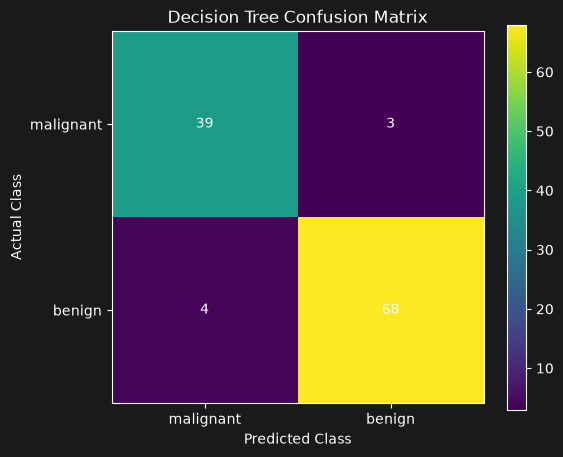

In [21]:
plt.figure(figsize=(6, 5))

plt.imshow(dt_cm)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.xticks(
    [0, 1],
    data.target_names
)

plt.yticks(
    [0, 1],
    data.target_names
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            dt_cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

## 22. DISPLAY KNN CONFUSION MATRIX

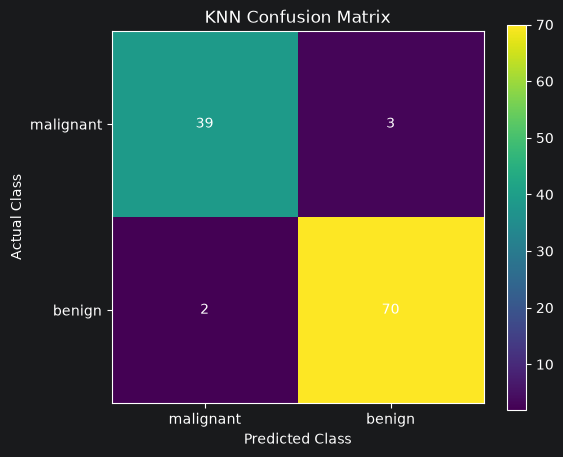

In [22]:
plt.figure(figsize=(6, 5))

plt.imshow(knn_cm)

plt.title("KNN Confusion Matrix")

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.xticks(
    [0, 1],
    data.target_names
)

plt.yticks(
    [0, 1],
    data.target_names
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            knn_cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

## 23. CREATE MODEL COMPARISON TABLE

In [23]:
comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],

    "Decision Tree": [
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1
    ],

    "KNN": [
        knn_accuracy,
        knn_precision,
        knn_recall,
        knn_f1
    ]
})


print("\n" + "=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)

print(comparison)


MODEL PERFORMANCE COMPARISON
      Metric  Decision Tree       KNN
0   Accuracy       0.938596  0.956140
1  Precision       0.957746  0.958904
2     Recall       0.944444  0.972222
3   F1-Score       0.951049  0.965517


## 24. ROUND VALUES FOR BETTER DISPLAY

In [24]:
comparison_rounded = comparison.copy()

comparison_rounded[
    ["Decision Tree", "KNN"]
] = comparison_rounded[
    ["Decision Tree", "KNN"]
].round(4)

print("\nRounded Comparison Table:")
print(comparison_rounded)


Rounded Comparison Table:
      Metric  Decision Tree     KNN
0   Accuracy         0.9386  0.9561
1  Precision         0.9577  0.9589
2     Recall         0.9444  0.9722
3   F1-Score         0.9510  0.9655


## 25. PERFORMANCE COMPARISON CHART

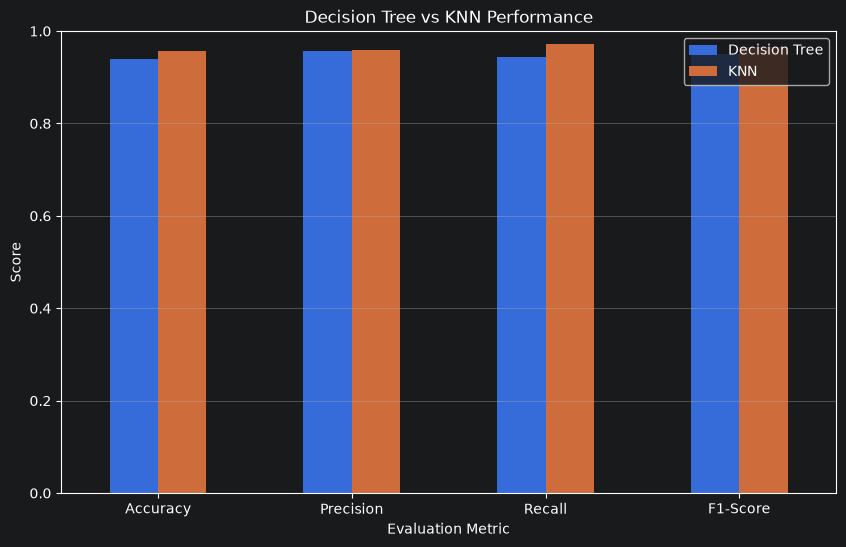

In [25]:
comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Decision Tree vs KNN Performance")

plt.xlabel("Evaluation Metric")

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend()

plt.grid(axis="y")

plt.show()

## 26. ACCURACY COMPARISON

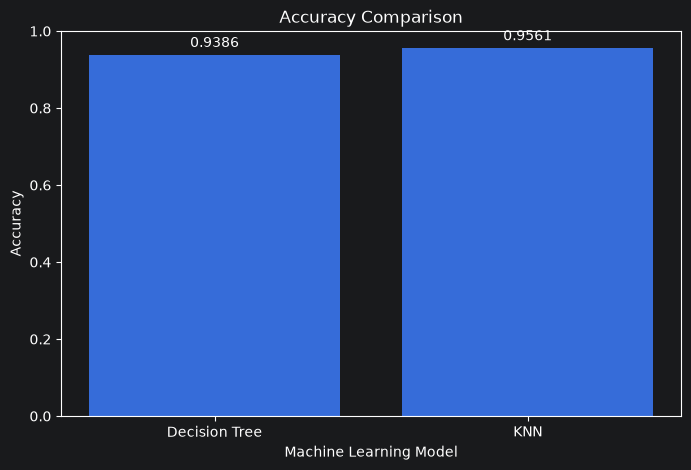

In [26]:
models = [
    "Decision Tree",
    "KNN"
]

accuracies = [
    dt_accuracy,
    knn_accuracy
]

plt.figure(figsize=(8, 5))

plt.bar(
    models,
    accuracies
)

plt.title("Accuracy Comparison")

plt.xlabel("Machine Learning Model")

plt.ylabel("Accuracy")

plt.ylim(0, 1)

for i, value in enumerate(accuracies):
    plt.text(
        i,
        value + 0.02,
        round(value, 4),
        ha="center"
    )

plt.show()

## 27. PRECISION COMPARISON

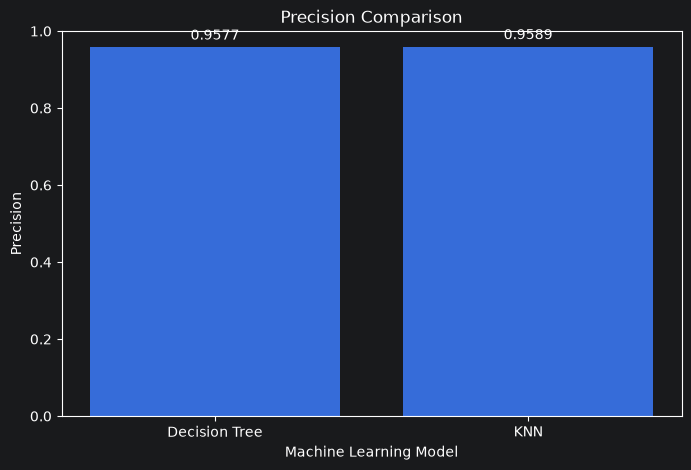

In [27]:
precisions = [
    dt_precision,
    knn_precision
]

plt.figure(figsize=(8, 5))

plt.bar(
    models,
    precisions
)

plt.title("Precision Comparison")

plt.xlabel("Machine Learning Model")

plt.ylabel("Precision")

plt.ylim(0, 1)

for i, value in enumerate(precisions):
    plt.text(
        i,
        value + 0.02,
        round(value, 4),
        ha="center"
    )

plt.show()

## 28. RECALL COMPARISON

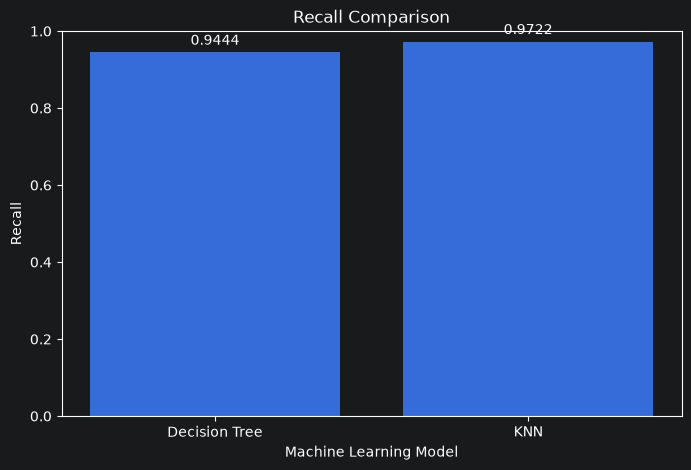

In [28]:
recalls = [
    dt_recall,
    knn_recall
]

plt.figure(figsize=(8, 5))

plt.bar(
    models,
    recalls
)

plt.title("Recall Comparison")

plt.xlabel("Machine Learning Model")

plt.ylabel("Recall")

plt.ylim(0, 1)

for i, value in enumerate(recalls):
    plt.text(
        i,
        value + 0.02,
        round(value, 4),
        ha="center"
    )

plt.show()

## 29. F1-SCORE COMPARISON

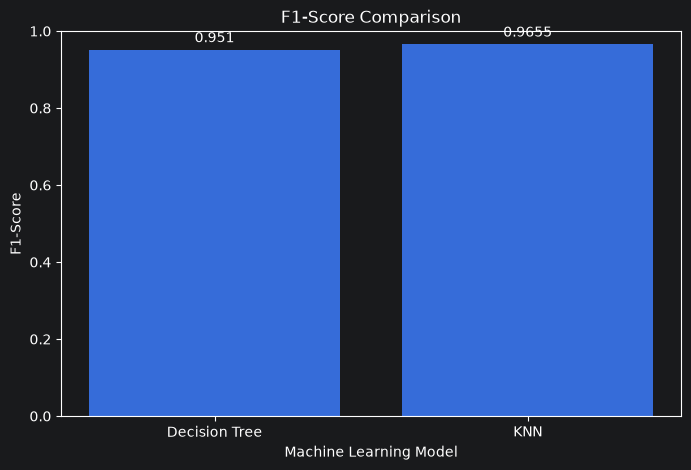

In [29]:
f1_scores = [
    dt_f1,
    knn_f1
]

plt.figure(figsize=(8, 5))

plt.bar(
    models,
    f1_scores
)

plt.title("F1-Score Comparison")

plt.xlabel("Machine Learning Model")

plt.ylabel("F1-Score")

plt.ylim(0, 1)

for i, value in enumerate(f1_scores):
    plt.text(
        i,
        value + 0.02,
        round(value, 4),
        ha="center"
    )

plt.show()

## 30. FIND THE BEST MODEL FOR EACH METRIC

In [30]:
print("\n" + "=" * 60)
print("BEST MODEL FOR EACH METRIC")
print("=" * 60)

if dt_accuracy > knn_accuracy:
    print("Accuracy  : Decision Tree")
elif knn_accuracy > dt_accuracy:
    print("Accuracy  : KNN")
else:
    print("Accuracy  : Both models")

if dt_precision > knn_precision:
    print("Precision : Decision Tree")
elif knn_precision > dt_precision:
    print("Precision : KNN")
else:
    print("Precision : Both models")

if dt_recall > knn_recall:
    print("Recall    : Decision Tree")
elif knn_recall > dt_recall:
    print("Recall    : KNN")
else:
    print("Recall    : Both models")

if dt_f1 > knn_f1:
    print("F1-Score  : Decision Tree")
elif knn_f1 > dt_f1:
    print("F1-Score  : KNN")
else:
    print("F1-Score  : Both models")


BEST MODEL FOR EACH METRIC
Accuracy  : KNN
Precision : KNN
Recall    : KNN
F1-Score  : KNN


## 31. OVERALL MODEL COMPARISON

In [31]:
dt_average = np.mean([
    dt_accuracy,
    dt_precision,
    dt_recall,
    dt_f1
])

knn_average = np.mean([
    knn_accuracy,
    knn_precision,
    knn_recall,
    knn_f1
])

print("\n" + "=" * 60)
print("OVERALL MODEL PERFORMANCE")
print("=" * 60)

print(
    "Decision Tree Average Score:",
    round(dt_average, 4)
)

print(
    "KNN Average Score:",
    round(knn_average, 4)
)


OVERALL MODEL PERFORMANCE
Decision Tree Average Score: 0.948
KNN Average Score: 0.9632


## 32. DETERMINE BETTER MODEL

In [32]:
print("\n" + "=" * 60)
print("FINAL RESULT")
print("=" * 60)

if dt_average > knn_average:

    print(
        "Decision Tree performed better overall "
        "based on the average evaluation score."
    )

elif knn_average > dt_average:

    print(
        "KNN performed better overall "
        "based on the average evaluation score."
    )

else:

    print(
        "Both models performed equally "
        "based on the average evaluation score."
    )


FINAL RESULT
KNN performed better overall based on the average evaluation score.


## 33. CREATE FINAL EVALUATION REPORT

In [33]:
evaluation_report = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "KNN"
    ],

    "Accuracy": [
        dt_accuracy,
        knn_accuracy
    ],

    "Precision": [
        dt_precision,
        knn_precision
    ],

    "Recall": [
        dt_recall,
        knn_recall
    ],

    "F1-Score": [
        dt_f1,
        knn_f1
    ]
})


# Round values
evaluation_report[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
] = evaluation_report[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].round(4)


print("\n" + "=" * 60)
print("MODEL EVALUATION REPORT")
print("=" * 60)

print(evaluation_report)


MODEL EVALUATION REPORT
           Model  Accuracy  Precision  Recall  F1-Score
0  Decision Tree    0.9386     0.9577  0.9444    0.9510
1            KNN    0.9561     0.9589  0.9722    0.9655


## 34. FINAL SUMMARY

In [34]:
print("\n" + "=" * 60)
print("WEEK 3 – DAY 5 FINAL SUMMARY")
print("=" * 60)

print("\nDataset:")
print("Breast Cancer Wisconsin Dataset")

print("\nModels Evaluated:")
print("1. Decision Tree")
print("2. K-Nearest Neighbors (KNN)")

print("\nEvaluation Metrics:")
print("1. Accuracy")
print("2. Precision")
print("3. Recall")
print("4. F1-Score")

print("\nDecision Tree:")
print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1-Score :", round(dt_f1, 4))

print("\nKNN:")
print("Accuracy :", round(knn_accuracy, 4))
print("Precision:", round(knn_precision, 4))
print("Recall   :", round(knn_recall, 4))
print("F1-Score :", round(knn_f1, 4))

print("\n" + "=" * 60)
print("DAY 5 COMPLETED SUCCESSFULLY!")
print("=" * 60)


WEEK 3 – DAY 5 FINAL SUMMARY

Dataset:
Breast Cancer Wisconsin Dataset

Models Evaluated:
1. Decision Tree
2. K-Nearest Neighbors (KNN)

Evaluation Metrics:
1. Accuracy
2. Precision
3. Recall
4. F1-Score

Decision Tree:
Accuracy : 0.9386
Precision: 0.9577
Recall   : 0.9444
F1-Score : 0.951

KNN:
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1-Score : 0.9655

DAY 5 COMPLETED SUCCESSFULLY!
